# 3.1- CLASIFICACIÓN CON KNN
*k-nearest neighbors* O K vecinos cercanos

## 1. Importamos los datos

In [124]:
# Conecto con el Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
import pandas as pd

## Importo el archivo
gym = pd.read_excel("/content/drive/MyDrive/Analitica de negocios/3. BD1-GymData.xlsx")

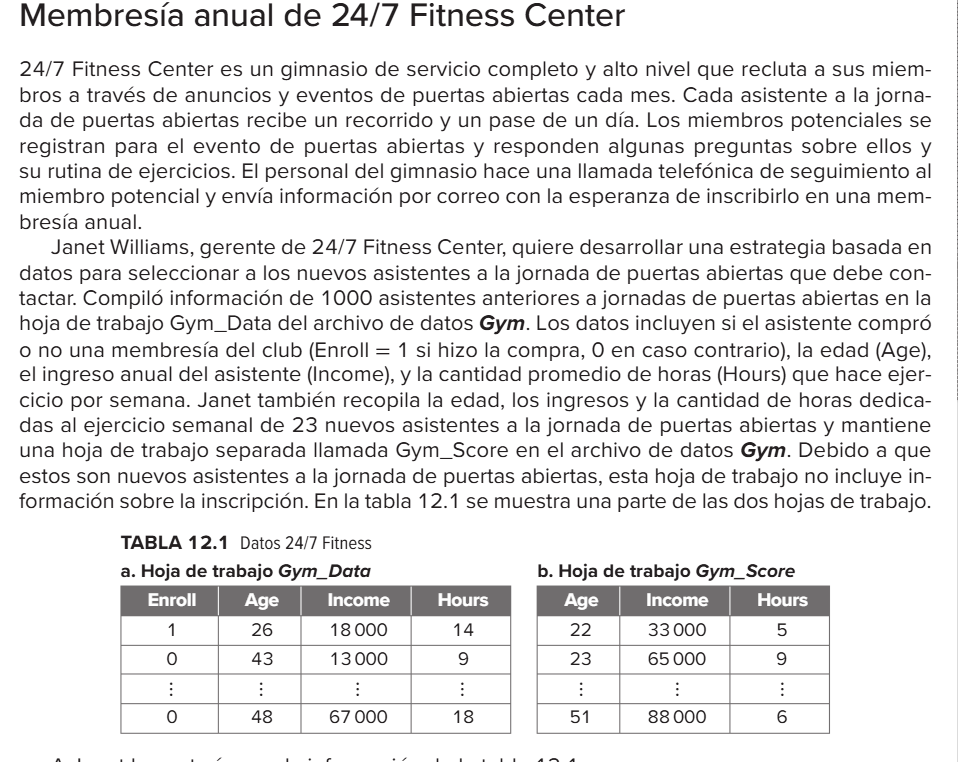

## 2. Limpiamos los datos

In [127]:
gym.shape

(1000, 4)

In [128]:
## Escojo solo las variables Edad, Ingresos, Egresos, Monto (EAD) que son las variables independientes del modelo
XD=gym[['Age', 'Income',	 'Hours']]
XD

,Age,Income,Hours
0,26,18000,14
1,43,13000,9
2,55,42000,16
3,55,100000,13
4,55,13000,12
...,...,...,...
995,39,5000,13
996,38,5000,3
997,55,70000,17
998,68,64000,15


In [129]:
## Escojo la variable dependiente del modelo
yd= gym['Enroll'].dropna()     ##(un solo corchete para convertirlo facil a array)

In [130]:
yd.shape

(1000,)

## 3. Analizamos la correlación de las variables

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning:

The `size` parameter has been renamed to `height`; please update your code.



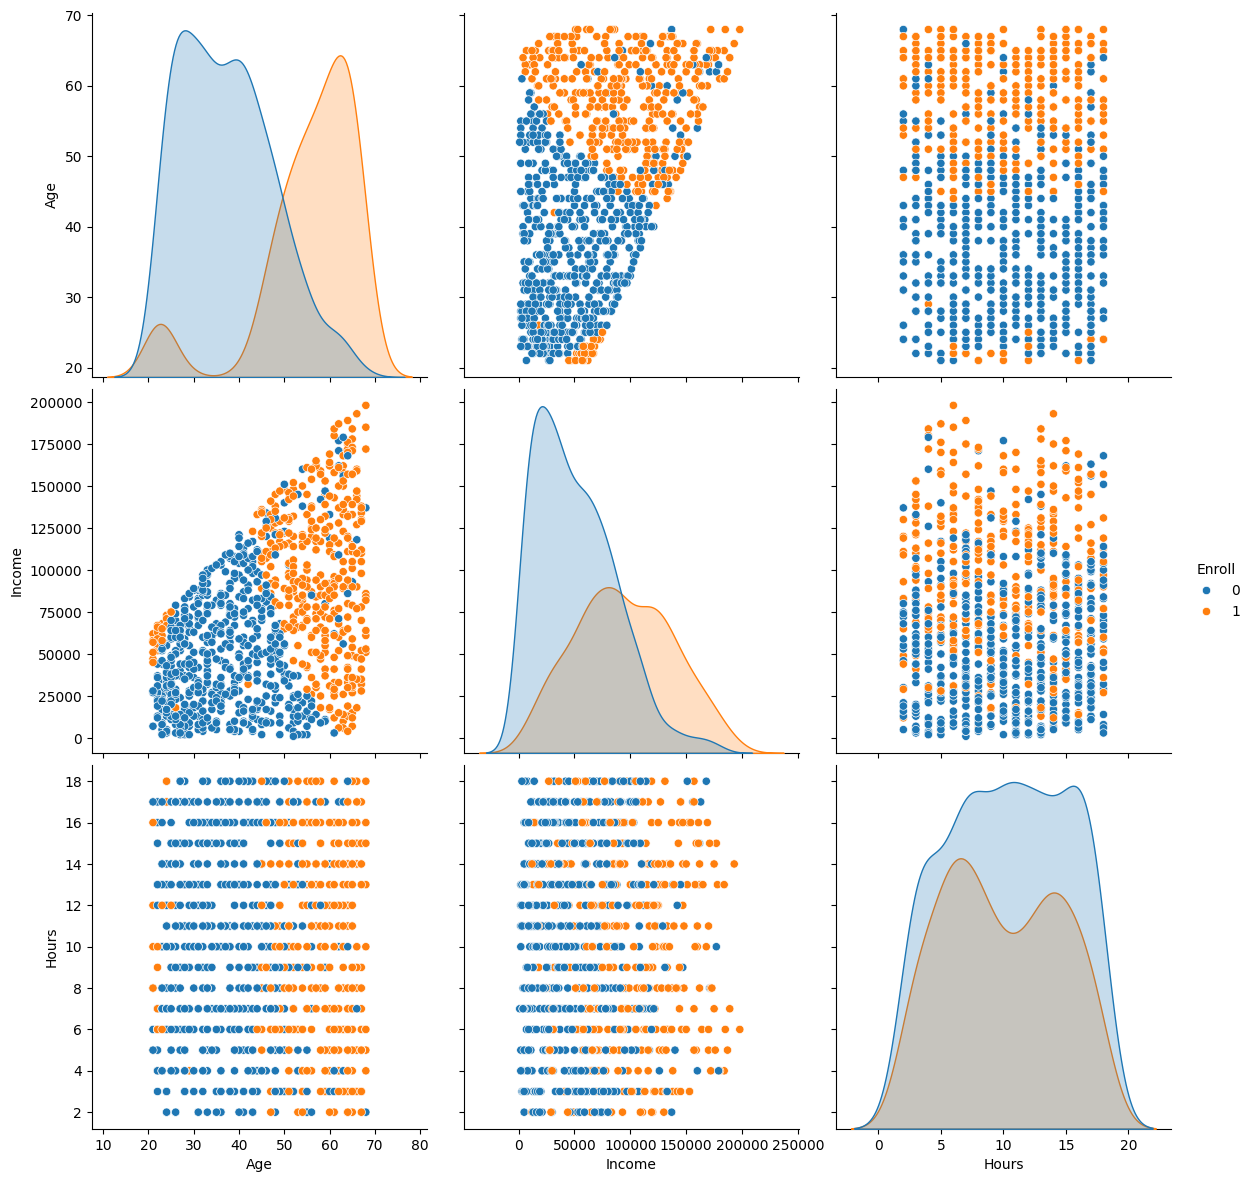

In [131]:
import seaborn as sns

#crear el dashboard
sns.pairplot(gym, hue='Enroll', size=4, vars=['Age','Income', 'Hours'])
#PARA QUE SEAN CORRELACIONADOS TIENE QUE ESTAR EN DIAGONAL FORMANDO UN CONO

In [132]:
import numpy as np
# Creamos la matriz de correlacion entre las variables
dfinf=pd.DataFrame(np.column_stack((XD,yd)))
dfinf.columns=['Age', 'Income', 'Hours', 'Enroll']
mCorr=dfinf.corr()
mCorr
#Hours ES VARIABLE DESCARTABLE PORQUE TIENE POCA CORRELACIÓN, LAS DEMÁS SI TIENEN BUENOS COEFICIENTES

,Age,Income,Hours,Enroll
Age,1.000000,0.450562,-0.040133,0.644033
Income,0.450562,1.000000,-0.018196,0.476372
Hours,-0.040133,-0.018196,1.000000,-0.048184
Enroll,0.644033,0.476372,-0.048184,1.000000


<Axes: >

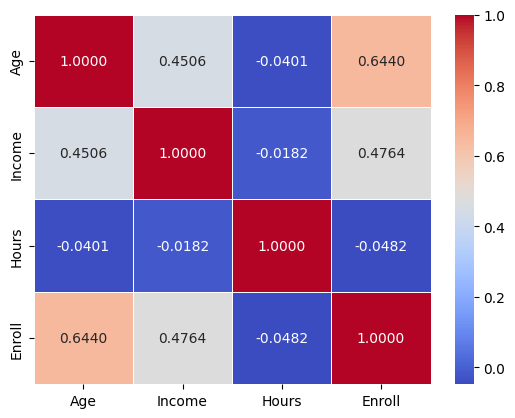

In [133]:
## Volvemos a graficar la matriz de correlación pero ahora como un mapa de calor
sns.heatmap(mCorr, cmap='coolwarm', linewidths=.5, annot=True, fmt=".4f")

##4.Implementar el modelo KNN

In [134]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

In [135]:
### Creamos la variable que aloja al modelo
knnModel = KNeighborsClassifier(n_neighbors=10)

In [136]:
## ENTRENAMOS EL MODELO
knnModel.fit(XD, yd)

KNeighborsClassifier(n_neighbors=10)

In [137]:
ydpred = knnModel.predict(XD)

In [138]:
##Creo la matriz de confusion
cm = confusion_matrix(yd, ydpred)

In [139]:
## extraigo los valores de la matriz de confusion
VN = cm[0,0] ; FP = cm[0,1] ; FN = cm[1,0] ; VP = cm[1,1]

In [140]:
## Metricas de evaluacion del modelo
exactitud= (VN+VP)/cm.sum()
error= 1-exactitud
precision= VP/(VP+FP)
sensibilidad= VP/(VP+FN)
especificidad= VN/(VN+FP)

In [141]:
## ejemplo de impresion de las metricas de evaluacion
print(f'La exactitud del modelo es {exactitud:.2%}')
print(f'El error del modelo es {error:.2%}')
print(f'La precision del modelo es {precision:.2%}')
print(f'La sensibilidad del modelo es {sensibilidad:.2%}')
print(f'La especificidad del modelo es {especificidad:.2%}')

La exactitud del modelo es 79.60%
El error del modelo es 20.40%
La precision del modelo es 81.39%
La sensibilidad del modelo es 64.02%
La especificidad del modelo es 90.12%


###6.Hacemos el pronostico para un solo solicitante

In [142]:
XDi = [26, 800, 15]

In [143]:
##Convierto los datos a un df y le asigno nombres a las columnas
XDi_df = pd.DataFrame([XDi], columns=XD.columns)

In [144]:
ydi = knnModel.predict(XDi_df)
print(f'La decision frente a si compra la membresia es {ydi} es decir {'la compro' if ydi[0]==1 else 'no la compro'}')

La decision frente a si compra la membresia es [0] es decir no la compro


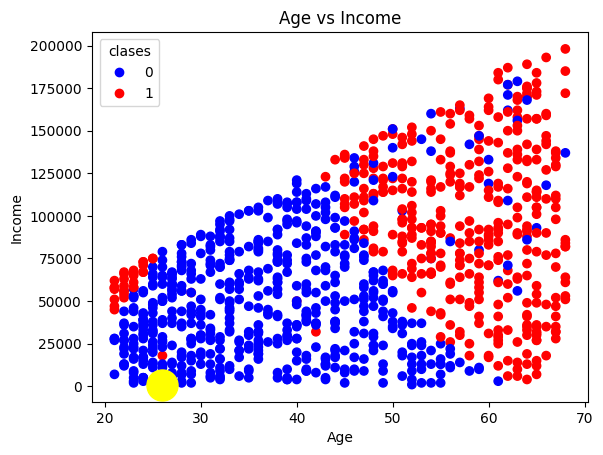

In [145]:
###Graficamos este solicitante en un grafico de dispersion
import matplotlib.pyplot as plt
scatter = plt.scatter(XD['Age'], XD['Income'],
                      c=yd,
                      cmap='bwr')
plt.scatter(XDi_df['Age'], XDi_df ['Income'], facecolor='yellow', s=500)
plt.title('Age vs Income')
plt.show
plt.legend(title='clases', *scatter.legend_elements(), bbox_to_anchor=(0.15, 1))
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

#3.2 Clusterizacion con Kmeans

In [147]:
from sklearn.cluster import KMeans

#Creamos una semilla de 42 valores
np.random.seed(42)

## Definimos que el modelo va a tener 5 grupos de datos
k=5

In [148]:
##Creamos la variable que aloja el modelo
kMeansModel = KMeans(n_clusters=k, init='random', random_state=42)

In [149]:
##Entrenamos el modelo
kMeansModel.fit(XD, yd)

KMeans(init='random', n_clusters=5, random_state=42)

In [150]:
## Extraer las etiquetas de los clusteres de los solicitantes
labels = kMeansModel.labels_

##3.2.2 Graficamos los clusteres y a nuestro solicitante

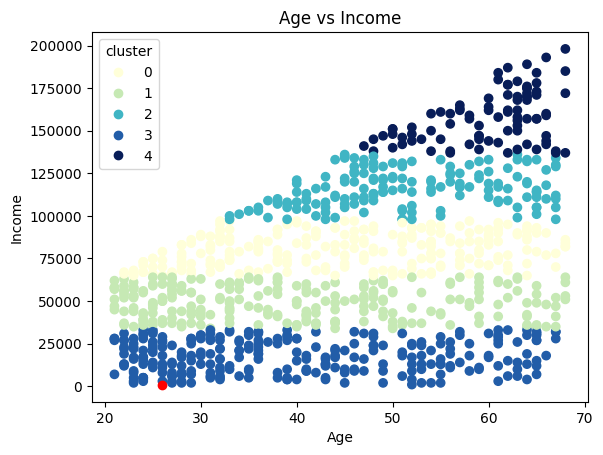

In [151]:
scatter = plt.scatter(XD['Age'], XD['Income'],
                      c=labels, cmap='YlGnBu')
plt.scatter(XDi_df['Age'], XDi_df ['Income'], facecolor='red')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.legend(title='cluster', *scatter.legend_elements())
plt.show()

In [152]:
### Predecimos el cluster de nuestro solicitante
kMeansModel.predict(XDi_df)

array([3], dtype=int32)

In [153]:
## Generamos los centroides
centroids = kMeansModel.cluster_centers_
centroids

array([[4.48577236e+01, 8.01463415e+04, 1.03333333e+01],
       [3.97478992e+01, 4.93655462e+04, 1.02815126e+01],
       [5.12611465e+01, 1.15770701e+05, 9.80891720e+00],
       [3.96900369e+01, 1.77601476e+04, 1.01881919e+01],
       [6.00340909e+01, 1.57795455e+05, 1.01363636e+01]])

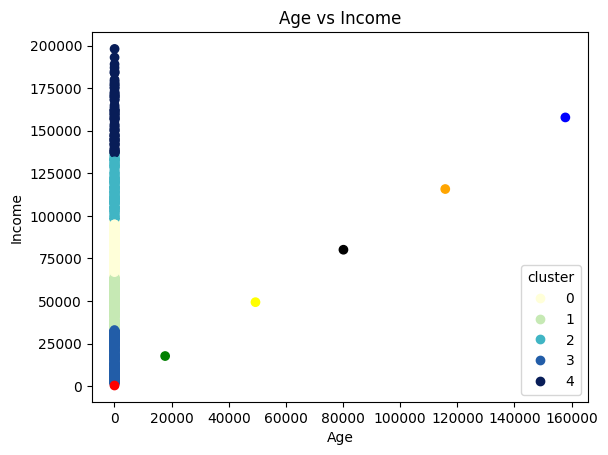

In [154]:
scatter = plt.scatter(XD['Age'], XD['Income'],
                      c=labels, cmap='YlGnBu')
plt.scatter(XDi_df['Age'], XDi_df ['Income'], facecolor='red')
plt.scatter(centroids[:,1], centroids[:,1],
            facecolor=['black', 'yellow', 'orange', 'green', 'blue'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.legend(title='cluster', *scatter.legend_elements())
plt.show()

###3.2.3 Generamos los informes de los clusteres

In [155]:
## Necesito primero completar el df original con una nueva columna donde se indique el cluster para cada solicitante.
gym.loc[:,'cluster']=labels ## Asigno las etiquetas de cluster a los datos, creando una columna 'cluster'

import plotly.express as px, plotly.graph_objects as go

fig = px.scatter_3d(gym.astype({'cluster':str}),'Age', 'Income', 'Hours', color='cluster', opacity=1)
# Convierto la figura a una tipo go.Figure para añadirle más puntos
fig = go.Figure(fig)

#Creo el punto para el nuevo solicitante
fig.add_trace(go.Scatter3d(x=[XDi[0]],y=[XDi[1]],z=[XDi[2]], name='Solicitante', marker=dict(color='red'), mode='markers'))

##Grafico los centroides
fig.add_trace(go.Scatter3d(x=centroids[:,0].tolist(),
                           y=centroids[:,1].tolist(),
                           z=centroids[:,2].tolist(),
                           name='Centroides',
                           marker=dict(color='black'),
                           mode='markers'))
#Ploteo
fig.show()

In [156]:

gym.loc[:,'cluster']=labels
counts_0 = gym.groupby('cluster').agg({'Enroll' : lambda x: (x==0).sum()})
counts_1 = gym.groupby('cluster').agg({'Enroll' : lambda x: (x==1).sum()})

##creamos un df con esas dos cuentas
df = pd.DataFrame(np.column_stack((counts_0, counts_1)))
df.columns=['NoEnroll', 'SiEnroll']
df['Total']=df.sum(axis=1)
df['pronNoEnroll']=df['NoEnroll']/df['Total']
df['pronSiEnroll']=df['SiEnroll']/df['Total']
df

,NoEnroll,SiEnroll,Total,pronNoEnroll,pronSiEnroll
0,130,116,246,0.528455,0.471545
1,172,66,238,0.722689,0.277311
2,50,107,157,0.318471,0.681529
3,230,41,271,0.848708,0.151292
4,15,73,88,0.170455,0.829545


In [169]:

# Filtramos  solamente los individuos que SÍ harán parte de la membresía
df_ins = gym[gym['Enroll'] == 1]

# --- Calcular centroides ---
centroidsNew = df_ins.groupby('cluster')[['Age','Income','Hours']].mean()

print(centroidsNew.round(3))

# --- identificar el cluster que presenta la mayor edad, los mayores ingresos y horas ---
ranked = centroidsNew.rank(ascending=False, method='min')
ranked['rank_sum'] = ranked.sum(axis=1)
print(ranked)
ElCluster = ranked['rank_sum'].idxmin()
print(f"\n El cluster que presenta la mayor edad, los mayores ingresos y horas es el cluster indice[{ElCluster}] ")


            Age      Income   Hours
cluster                            
0        53.284   81034.483  10.086
1        50.833   51393.939  10.212
2        55.215  118242.991   9.383
3        60.976   22731.707  10.195
4        60.329  158219.178   9.959
         Age  Income  Hours  rank_sum
cluster                              
0        4.0     3.0    3.0      10.0
1        5.0     4.0    1.0      10.0
2        3.0     2.0    5.0      10.0
3        1.0     5.0    2.0       8.0
4        2.0     1.0    4.0       7.0

 El cluster que presenta la mayor edad, los mayores ingresos y horas es el cluster indice[4] 


###Analisis



-*Describir en el análisis de resultados cada una de las variables que
hacen parte de la base de datos.*

Enroll: Si el asistente Compro o no una membresia del Gym

Age: Edad de las personas de la base de datos

Income: Ingresos Anuales de las persona

Hour: Horas semanas que pasa la persona entrenando

-*Determinar la variable que mejor lleva a cabo el proceso de
caracterización de la inscripción de una persona al Gym.*

La variable que mejor lleva a cabo el proceso de caracterizacion es Age ya que es la que tiene mas correlaccion con Enroll (0.644033)


-*Según las variables de entrada y de salida, determinar cuáles variables
tienen una mayor correlación entre ellas.*

Las Variables independientes que mas tienen correlacion son Age y Income (0.450562)



-*Indicar cual es el clúster que presenta la mayor edad, los mayores
ingresos y estarán en el gimnasio por un mayor número de horas,
tomando como base solamente los individuos que SÍ harán parte de la
membresía.*

Cluster 5 indice [4]